In [31]:
# Import modules
import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *

import numpy as np 
import matplotlib.pyplot as plt
from NuOscProbExact.src import  oscprob2nu, globaldefs, hamiltonians2nu
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
import copy as cp

In [32]:
def gaus(x,p0,p1,p2):
    return p0 * math.e**((-0.5 * (x - p1)**2)/ p2**2)

# Function to generate counts from a Poisson distribution based on probabilities and Gaussian scaling    
def poisson_dist(probability, bin_centers, amplitude, mean, sigma):
    counts = np.random.poisson(probability * gaus(bin_centers,amplitude,mean,sigma)) 
    return counts


In [33]:
# parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])

length_nd = 1 # [km]
length_fd = 810 # [km]

Fitted parameters for observed the unoscillated ND events: Amplitude = 212.76692699546734, Mean = 1.8044188236655974, Sigma = 0.5254484171717854
Fitted parameters for observed the oscillated FD events: Amplitude = 13.876745944019577, Mean = 2.211417891318019, Sigma = 0.4952413577763477


Text(0.5, 0, 'Energy (GeV)')

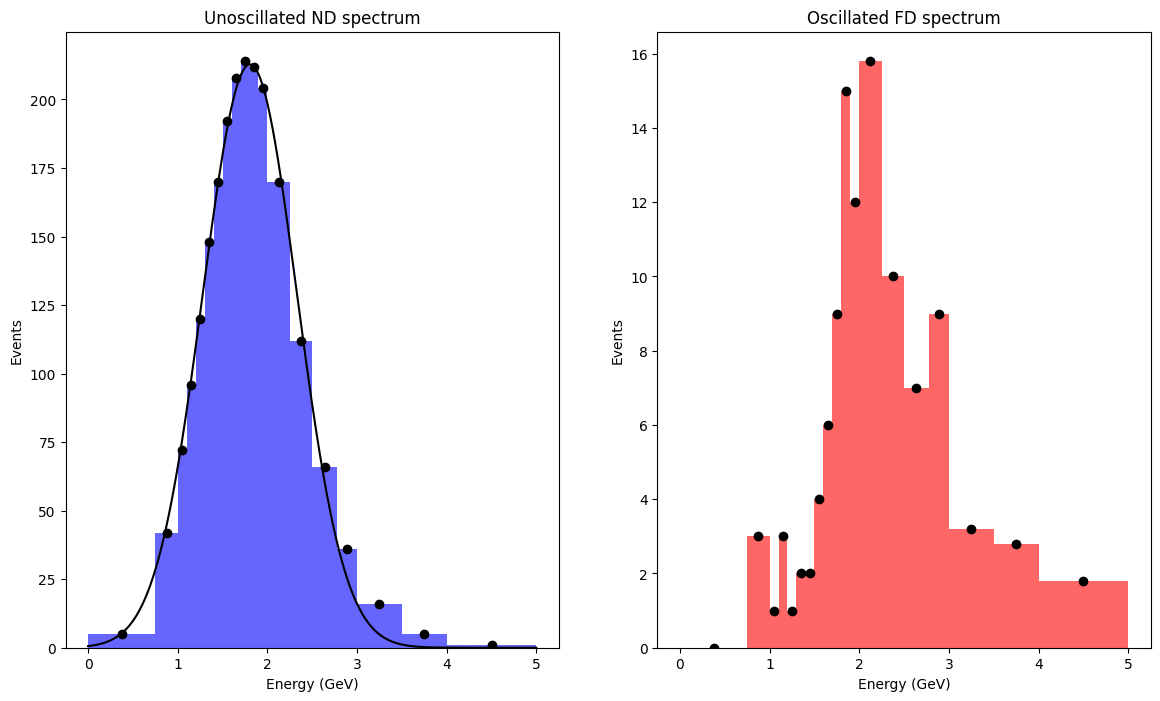

In [34]:
initial_guess_nd = [140,2,0.5]
initial_guess_fd = [8, 2, 0.5]

popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=initial_guess_nd)
popt_fd, _ = curve_fit(gaus, bin_centers, counts_fd, p0=initial_guess_fd)

print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")
print(f"Fitted parameters for observed the oscillated FD events: Amplitude = {popt_fd[0]}, Mean = {popt_fd[1]}, Sigma = {popt_fd[2]}")

fig, axs = plt.subplots(1, 2, figsize=(14, 8))

x = np.arange(0,5,0.001)

axs[0].hist(bin_edges[:-1],bin_edges ,weights=counts_nd, density=False, alpha=0.6, color='b')
axs[0].scatter(bin_centers, counts_nd, color='black')
axs[0].plot(x, gaus(x,*popt_nd), color='black')
axs[0].set_title("Unoscillated ND spectrum")
axs[0].set_ylabel("Events")
axs[0].set_xlabel("Energy (GeV)")

axs[1].hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.6, color='r')
axs[1].scatter(bin_centers, counts_fd, color='black')
#axs[1].plot(x, gaus(x, *popt_fd), color='black')
axs[1].set_title("Oscillated FD spectrum")
axs[1].set_ylabel("Events")
axs[1].set_xlabel("Energy (GeV)")

In [35]:
def osc_probability_2nu(sector, case, length, transition):
    """
    Calculate oscillation probabilities for 2-neutrino systems.

    Parameters:
    - sector: str, '12' or '23'
    - case: str, 'vacuum' or 'matter'
    - length: float, in kilometers
    - transition: str, 'me', 'mm', or 'mt'

    Returns:
    - List of probabilities for the specified transition
    """
    # Convert energy to eV
    energy = bin_centers * 1e9
    probabilities = []

    # Sector-specific parameters
    if sector == '12':
        mixing_angle = globaldefs.S12_NO_BF
        delta_mass_squared = globaldefs.D21_NO_BF
        transition_map = {'me': 2, 'mm': 3}
    elif sector == '23':
        mixing_angle = globaldefs.S23_NO_BF
        delta_mass_squared = globaldefs.D31_NO_BF
        transition_map = {'mm': 0, 'mt': 1}
    else:
        raise ValueError(f"Invalid sector '{sector}'. Must be '12' or '23'.")

    # Determine the index for the transition
    index1 = transition_map.get(transition)
    if index1 is None:
        raise ValueError(f"Invalid transition '{transition}'. Must match the sector.")

    # Calculate energy-independent vacuum Hamiltonian
    h_vacuum_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(mixing_angle, delta_mass_squared)
    print(h_vacuum_energy_indep)

    # Scaling factor for length
    length_scaled = length * globaldefs.CONV_KM_TO_INV_EV

    # Define a function for Hamiltonian calculation
    if case == 'vacuum':
        def calculate_hamiltonian(e): return h_vacuum_energy_indep / e
    elif case == 'matter':
        def calculate_hamiltonian(e): return hamiltonians2nu.hamiltonian_2nu_matter(h_vacuum_energy_indep, e, globaldefs.VCC_EARTH_CRUST)
    else:
        raise ValueError(f"Invalid case '{case}'. Must be 'vacuum' or 'matter'.")
    
    # Compute probabilities
    probabilities = [
        oscprob2nu.probabilities_2nu(calculate_hamiltonian(e), length_scaled)[index1]
        for e in energy
    ]

    return probabilities


In [36]:
def plot_osc_2nu(sector, case, length, transition):
    # Calculate the oscillation probabilities based on the specified sector, case, and length
    """
    Parameters:
    - sector: str, oscillation sector ('12' or '23')
    - case: str, either 'vacuum' or 'matter'
    - length: int, detector length (1, 810)
    - transition: str, type of transition ('me', 'mm', 'mt')
    """
    # Calculate the oscillatoin probabilities
    probabilities = osc_probability_2nu(sector, case, length, transition)
    print(f'Probabilitities: ', probabilities)
    
    popt = popt_nd
    weights = counts_nd

    # Maps the lengths to their repestive titles
    title_map = {
        length_nd: 'Unoscillated vs Oscillated Neutrino Events in ND',
        length_fd: 'Unoscillated vs Oscillated Neutrino Events in FD'
    }
    title_text1 = title_map.get(length, 'Unknown')
    fit_oscillation = (length == length_nd)
    title_text2 = 'In Matter' if case == 'matter' else 'In Vacuum'
    full_title = f'{title_text1} {title_text2}'

    # Set labels and event index based on the transition type
    label_map = {
        'me': ('μ → e events', 'Gaussian (μ → e) events fit', 2),
        'mt': ('μ → τ events', 'Gaussian (μ → τ) events fit', 2),
        'mm': ('μ → μ events', 'Gaussian (μ → μ) events fit', 0),
    }
    event_label, gaussian_fit_label, index = label_map.get(transition, ('Unknown transition', '', 0))

    # Calculate the Poisson-distributed counts for the oscillated events
    counts = poisson_dist(probabilities, bin_centers, *popt)
    counts_without_poisson_dist = probabilities * gaus(bin_centers, *popt)
    
    # Start plotting
    fig, axs = plt.subplots(1, 2, figsize=(14, 8))
    x = np.arange(0,5,0.001)

    # First subplot: with Poisson dist
    axs[0].hist(bin_edges[:-1],bin_edges ,weights=weights, histtype='step', alpha=0.6, color='r', label='Unoscillated Events')
    axs[0].plot(x, gaus(x,*popt_nd), color='green', label='Gaussian Unoscillated Events')
    axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts, histtype='step',density=False,
                alpha=0.6, color='b', label=event_label)

    if fit_oscillation:
        popt_osc, _ = curve_fit(gaus, bin_centers, counts)
        print(f"Fitted parameters for observed events: Amplitude = {popt_osc[0]}, Mean = {popt_osc[1]}, Sigma = {popt_osc[2]}")
        axs[0].plot(x, gaus(x, *popt_osc), color='black',label=gaussian_fit_label)

    axs[0].set_title(full_title)
    axs[0].set_xlabel('Energy (GeV)')
    axs[0].set_ylabel('Events')
    axs[0].legend()
    axs[0].grid()

    # Second subplot: without Poisson dist
    axs[1].hist(bin_edges[:-1],bin_edges ,weights=weights, histtype='step', alpha=0.6, color='r', label='Unoscillated Events')
    axs[1].plot(x, gaus(x,*popt_nd), color='green', label='Gaussian Unoscillated Events')
    axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_without_poisson_dist, histtype='step',density=False, 
                alpha=0.6, color='b', label=event_label)
    
    if fit_oscillation:
        popt_unfluc, _ = curve_fit(gaus, bin_centers, counts_without_poisson_dist)
        axs[1].plot(x, gaus(x, *popt_unfluc), color='black',label=gaussian_fit_label)

    axs[1].set_title(full_title + ' (No Poisson Fluctuations)')
    axs[1].set_xlabel('Energy (GeV)')
    axs[1].set_ylabel('Events')
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

In [37]:
def plot_osc_2nu_scaled_fd(sector, case, length,transition):
    """
    Plots the scaled FD oscillation spectrum against simulated FD oscillations.

    Parameters:
    - sector: str, oscillation sector ('12' or '23')
    - case: str, either 'vacuum' or 'matter'
    - length: int, detector length (1, 810)
    - transition: str, type of transition ('me', 'mm', 'mt')
    """

    popt = popt_nd

    # Calcualte osc prob
    probabilities = osc_probability_2nu(sector, case, length, transition)
    print(f'Probabilitities: ', probabilities)

    # Set title and labels
    title_text2 = 'In Matter' if case == 'matter' else 'In Vacuum'
    full_title = f'FD Oscillations vs Simulated FD Oscillations {title_text2}'

    label_map = {
        'me': ('μ → e events', 'Gaussian (μ → e) events fit', 2),
        'mt': ('μ → τ events', 'Gaussian (μ → τ) events fit', 2),
        'mm': ('μ → μ events', 'Gaussian (μ → μ) events fit', 0),
    }
    event_label, gaussian_fit_label, index = label_map.get(transition, ('Unknown transition', '', 0))
    
    # Calculate the Poisson-distributed counts for the oscillated events
    counts = poisson_dist(probabilities, bin_centers, *popt)
    unfluc_counts = probabilities * gaus(bin_centers, *popt)
    amount_count = np.sum(unfluc_counts)
    print(amount_count)

    # Calculate scale factor
    scale_factor = np.sum(counts_fd) / np.sum(counts_nd)
    scaled_counts = counts * scale_factor

    # Plotting
    plt.figure(figsize=(12,8))
    
    # FD spectrum histogram
    plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd, histtype='step',density=False,
             alpha=0.6, color='b', label='Oscillated FD spectrum')

    plt.hist(bin_edges[:-1], bins=bin_edges, weights=scaled_counts, histtype='step',density=False,
             alpha=0.6, color='r', label=event_label)

    # Labels and title to the plot
    plt.xlabel('Energy (GeV)')
    plt.ylabel('Events')
    plt.title(full_title)
    plt.legend()
    plt.grid()
    plt.show()

In [38]:
def osc_prob_2nu_sterile(sector, case, length):
    
    theta14 = np.sqrt(np.sin(0.0628319)**2)
    theta24 = np.sqrt(np.sin(0.0698132)**2)
    theta34 = np.sqrt(np.sin(0.3228859)**2)
    delta_mass_squared = 1.7 # [eV^2]

    # Convert energy to eV
    energy = bin_centers * 1e9
    probabilities = []

    if sector == '14':
        mixing_angle = theta14
    elif sector == '24':
        mixing_angle = theta24
    elif sector == '34':
        mixing_angle = theta34

    # Calculate energy-independent vacuum Hamiltonian
    h_vacuum_energy_indep = hamiltonians2nu.hamiltonian_2nu_vacuum_energy_independent(mixing_angle, delta_mass_squared)
    #print(h_vacuum_energy_indep)

    # Scaling factor for length
    length_scaled = length * globaldefs.CONV_KM_TO_INV_EV

    # Define a function for Hamiltonian calculation
    if case == 'vacuum':
        def calculate_hamiltonian(e): return h_vacuum_energy_indep / e
    elif case == 'matter':
        def calculate_hamiltonian(e): return hamiltonians2nu.hamiltonian_2nu_matter(h_vacuum_energy_indep, e, globaldefs.VCC_EARTH_CRUST)
    else:
        raise ValueError(f"Invalid case '{case}'. Must be 'vacuum' or 'matter'.")
    
    # Compute probabilities
    probabilities = [
        oscprob2nu.probabilities_2nu(calculate_hamiltonian(e), length_scaled)
        for e in energy
    ]

    return probabilities


[(0.9958510485714257, 0.004148951428574336, 0.004148951428574336, 0.9958510485714257), (0.9937872837623439, 0.006212716237656055, 0.006212716237656055, 0.9937872837623439), (0.9876467313251104, 0.012353268674889645, 0.012353268674889645, 0.9876467313251104), (0.9856817401042023, 0.014318259895797714, 0.014318259895797714, 0.9856817401042023), (0.9846527897615655, 0.0153472102384346, 0.0153472102384346, 0.9846527897615655), (0.9843010615464808, 0.01569893845351927, 0.01569893845351927, 0.9843010615464808), (0.984405915773789, 0.015594084226210994, 0.015594084226210994, 0.984405915773789), (0.9848020193579688, 0.015197980642031131, 0.015197980642031131, 0.9848020193579688), (0.9853728515679383, 0.014627148432061693, 0.014627148432061693, 0.9853728515679383), (0.9860391617707073, 0.013960838229292744, 0.013960838229292744, 0.9860391617707073), (0.9867484008568927, 0.013251599143107208, 0.013251599143107208, 0.9867484008568927), (0.9874665312144323, 0.012533468785567731, 0.0125334687855677

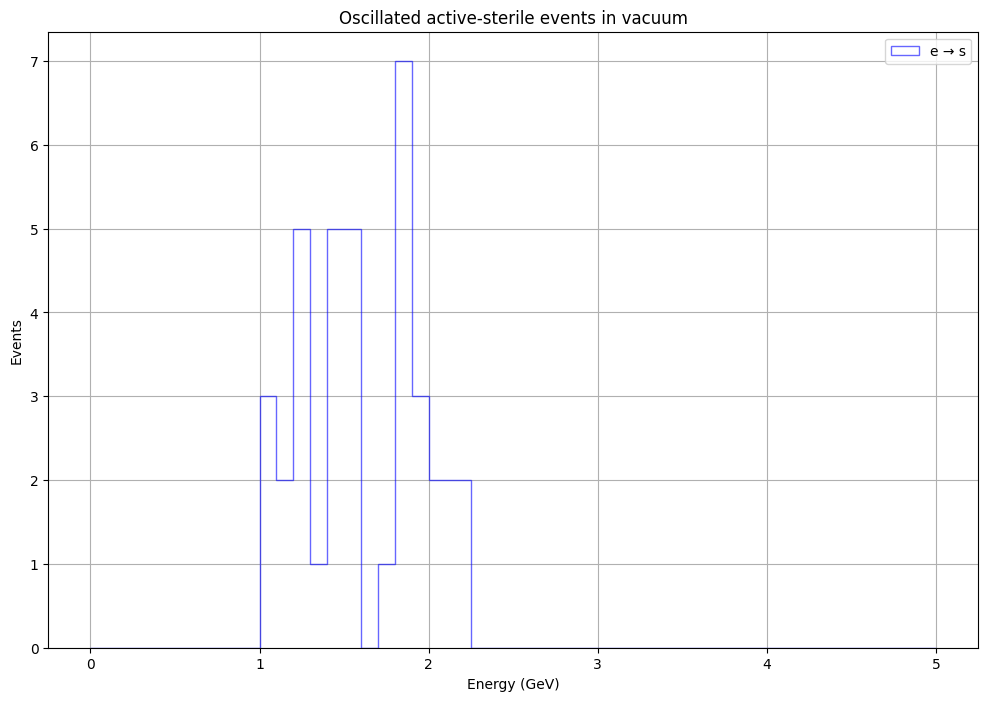

[(0.9948841689425086, 0.005115831057491352, 0.005115831057491352, 0.9948841689425086), (0.9923394604089393, 0.007660539591060726, 0.007660539591060726, 0.9923394604089393), (0.9847679018092889, 0.015232098190711111, 0.015232098190711111, 0.9847679018092889), (0.9823449852510505, 0.017655014748949455, 0.017655014748949455, 0.9823449852510505), (0.9810762463395211, 0.018923753660478947, 0.018923753660478947, 0.9810762463395211), (0.9806425507040085, 0.01935744929599148, 0.01935744929599148, 0.9806425507040085), (0.9807718403623252, 0.019228159637674797, 0.019228159637674797, 0.9807718403623252), (0.981260252688383, 0.01873974731161695, 0.01873974731161695, 0.981260252688383), (0.9819641127355906, 0.018035887264409422, 0.018035887264409422, 0.9819641127355906), (0.9827857011508639, 0.017214298849136004, 0.017214298849136004, 0.9827857011508639), (0.9836602226791966, 0.016339777320803356, 0.016339777320803356, 0.9836602226791966), (0.984545707517878, 0.015454292482122023, 0.015454292482122

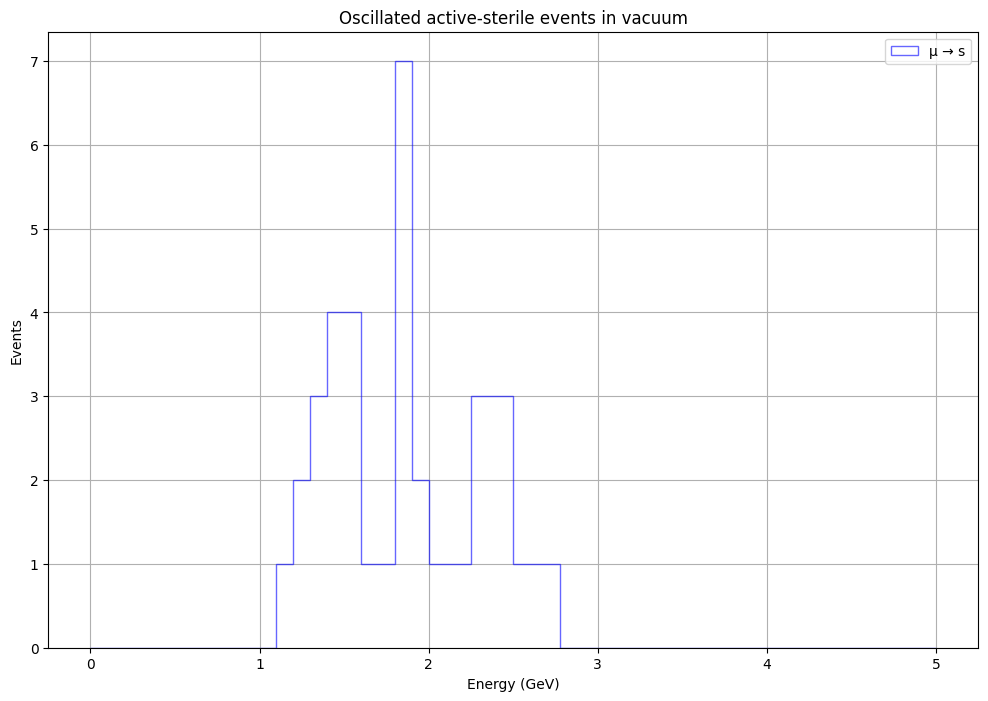

[(0.9043398099757782, 0.09566019002422171, 0.09566019002422171, 0.9043398099757782), (0.8567566706692046, 0.1432433293307954, 0.1432433293307954, 0.8567566706692046), (0.7151771841141381, 0.2848228158858619, 0.2848228158858619, 0.7151771841141381), (0.6698714154581322, 0.3301285845418678, 0.3301285845418678, 0.6698714154581322), (0.6461474488133947, 0.3538525511866053, 0.3538525511866053, 0.6461474488133947), (0.6380378364279247, 0.3619621635720753, 0.3619621635720753, 0.6380378364279247), (0.6404554051755538, 0.35954459482444623, 0.35954459482444623, 0.6404554051755538), (0.6495881570971499, 0.3504118429028501, 0.3504118429028501, 0.6495881570971499), (0.662749535006167, 0.33725046499383304, 0.33725046499383304, 0.662749535006167), (0.6781122987572621, 0.32188770124273797, 0.32188770124273797, 0.6781122987572621), (0.6944648511852924, 0.30553514881470756, 0.30553514881470756, 0.6944648511852924), (0.7110224049785878, 0.28897759502141224, 0.28897759502141224, 0.7110224049785878), (0.73

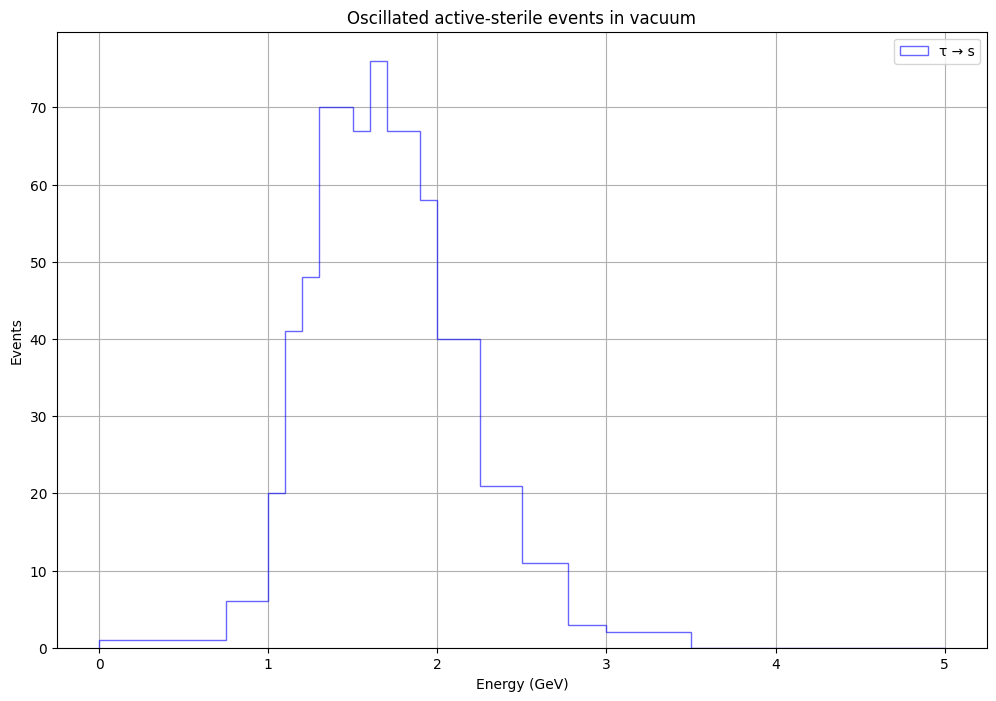

In [39]:
prob_theta14 = osc_prob_2nu_sterile('14','vacuum', length_nd)
print(prob_theta14)

counts14 = poisson_dist([t[1] for t in prob_theta14], bin_centers, *popt_nd)
print(counts14)

# Plotting
plt.figure(figsize=(12,8))
    
# FD spectrum histogram
plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts14, histtype='step',density=False,
             alpha=0.6, color='b', label='e → s')

# Labels and title to the plot
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.title('Oscillated active-sterile events in vacuum')
plt.legend()
plt.grid()
plt.show()

prob_theta24 = osc_prob_2nu_sterile('24','vacuum', length_nd)
print(prob_theta24)

counts24 = poisson_dist([t[1] for t in prob_theta24], bin_centers, *popt_nd)
print(counts24)

# Plotting
plt.figure(figsize=(12,8))
    
# FD spectrum histogram
plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts24, histtype='step',density=False,
             alpha=0.6, color='b', label='μ → s')

# Labels and title to the plot
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.title('Oscillated active-sterile events in vacuum')
plt.legend()
plt.grid()
plt.show()

prob_theta34 = osc_prob_2nu_sterile('34','vacuum', length_nd)
print(prob_theta34)

counts34 = poisson_dist([t[1] for t in prob_theta34], bin_centers, *popt_nd)
print(counts34)

# Plotting
plt.figure(figsize=(12,8))
    
# FD spectrum histogram
plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts34, histtype='step',density=False,
             alpha=0.6, color='b', label='τ → s')

# Labels and title to the plot
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.title('Oscillated active-sterile events in vacuum')
plt.legend()
plt.grid()
plt.show()

[(0.9958554140229419, 0.004144585977058123, 0.004144585977058123, 0.9958554140229419), (0.9937931086846407, 0.00620689131535939, 0.00620689131535939, 0.9937931086846407), (0.9876538446182469, 0.012346155381753115, 0.012346155381753115, 0.9876538446182469), (0.9856886517347366, 0.014311348265263325, 0.014311348265263325, 0.9856886517347366), (0.9846592191800874, 0.01534078081991261, 0.01534078081991261, 0.9846592191800874), (0.9843069000678213, 0.01569309993217873, 0.01569309993217873, 0.9843069000678213), (0.984411147291254, 0.015588852708745998, 0.015588852708745998, 0.984411147291254), (0.9848066737747495, 0.015193326225250511, 0.015193326225250511, 0.9848066737747495), (0.9853769788841534, 0.014623021115846544, 0.014623021115846544, 0.9853769788841534), (0.9860428182575536, 0.013957181742446374, 0.013957181742446374, 0.9860428182575536), (0.9867516420389119, 0.013248357961088116, 0.013248357961088116, 0.9867516420389119), (0.9874694085906183, 0.012530591409381715, 0.0125305914093817

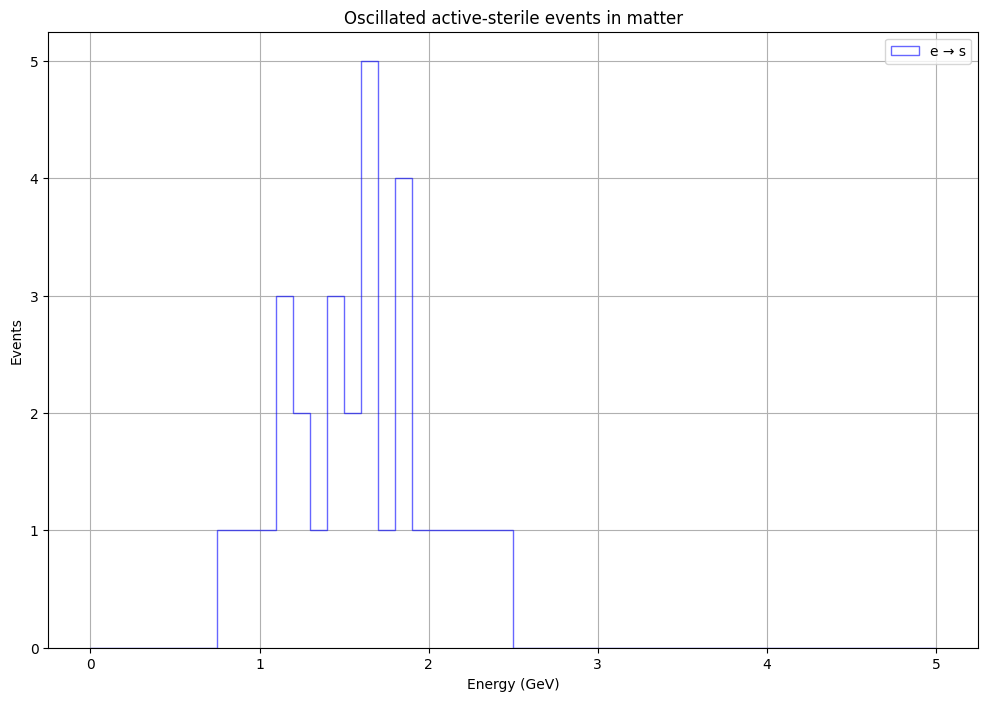

[(0.9948895417110972, 0.005110458288902801, 0.005110458288902801, 0.9948895417110972), (0.9923466294188252, 0.007653370581174755, 0.007653370581174755, 0.9923466294188252), (0.9847766564770545, 0.015223343522945559, 0.015223343522945559, 0.9847766564770545), (0.9823534917226927, 0.0176465082773073, 0.0176465082773073, 0.9823534917226927), (0.9810841593297381, 0.018915840670261894, 0.018915840670261894, 0.9810841593297381), (0.9806497364489176, 0.01935026355108239, 0.01935026355108239, 0.9806497364489176), (0.9807782790387227, 0.01922172096127728, 0.01922172096127728, 0.9807782790387227), (0.9812659810995857, 0.018734018900414255, 0.018734018900414255, 0.9812659810995857), (0.9819691924191396, 0.018030807580860387, 0.018030807580860387, 0.9819691924191396), (0.9827902013624024, 0.017209798637597695, 0.017209798637597695, 0.9827902013624024), (0.9836642117554164, 0.01633578824458354, 0.01633578824458354, 0.9836642117554164), (0.9845492488410356, 0.01545075115896444, 0.01545075115896444, 

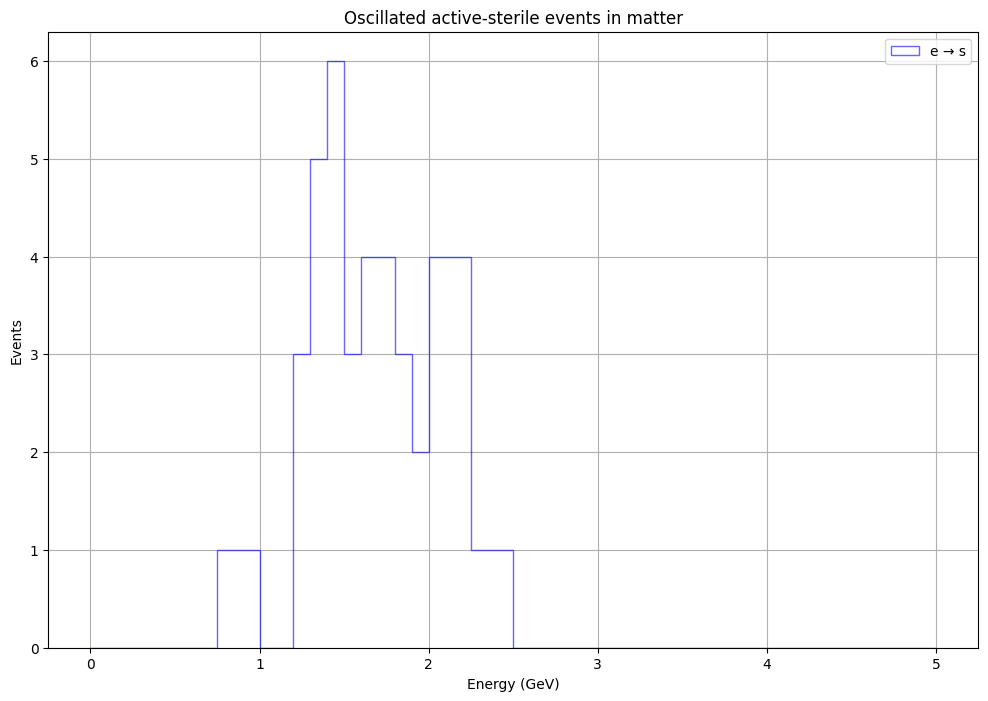

[(0.9044208376747299, 0.09557916232527008, 0.09557916232527008, 0.9044208376747299), (0.8568647899628785, 0.14313521003712146, 0.14313521003712146, 0.8568647899628785), (0.715309215039307, 0.28469078496069294, 0.28469078496069294, 0.715309215039307), (0.6699997027338213, 0.33000029726617874, 0.33000029726617874, 0.6699997027338213), (0.6462667854047575, 0.3537332145952425, 0.3537332145952425, 0.6462667854047575), (0.6381462051910084, 0.3618537948089916, 0.3618537948089916, 0.6381462051910084), (0.6405525072547407, 0.3594474927452593, 0.3594474927452593, 0.6405525072547407), (0.6496745475854251, 0.35032545241457486, 0.35032545241457486, 0.6496745475854251), (0.6628261419894752, 0.33717385801052485, 0.33717385801052485, 0.6628261419894752), (0.67818016670287, 0.3218198332971301, 0.3218198332971301, 0.67818016670287), (0.6945250106920715, 0.30547498930792855, 0.30547498930792855, 0.6945250106920715), (0.7110758119215375, 0.28892418807846254, 0.28892418807846254, 0.7110758119215375), (0.73

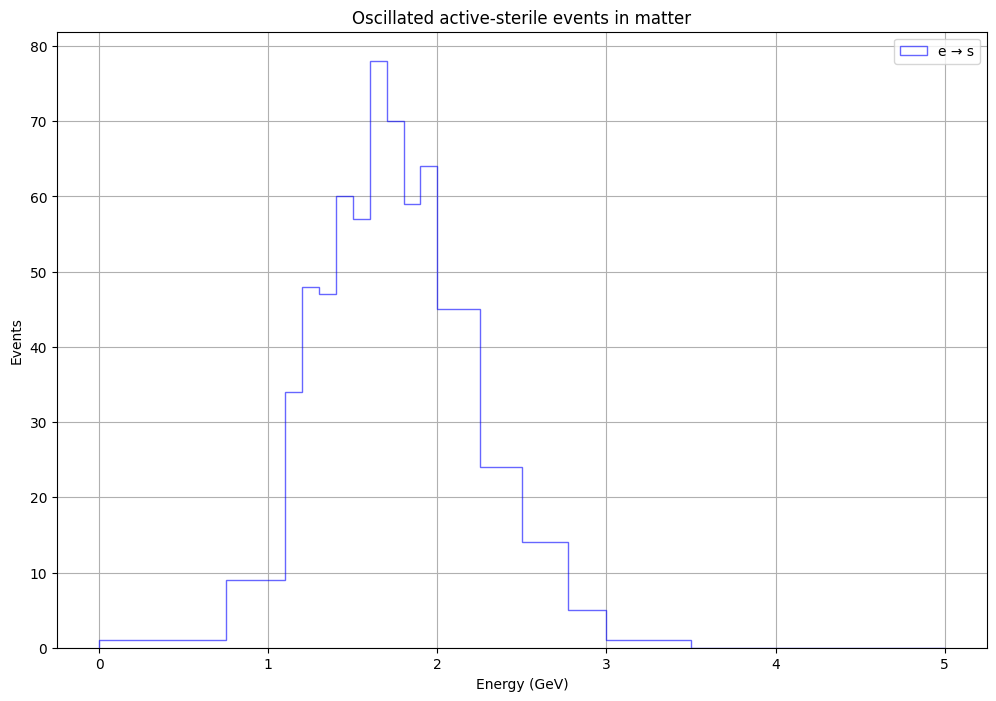

In [40]:
prob_theta14_matter = osc_prob_2nu_sterile('14','matter', length_nd)
print(prob_theta14_matter)

counts14_matter = poisson_dist([t[1] for t in prob_theta14_matter], bin_centers, *popt_nd)
print(counts14_matter)

# Plotting
plt.figure(figsize=(12,8))
    
# FD spectrum histogram
plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts14_matter, histtype='step',density=False,
             alpha=0.6, color='b', label='e → s')

# Labels and title to the plot
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.title('Oscillated active-sterile events in matter')
plt.legend()
plt.grid()
plt.show()

prob_theta24_matter = osc_prob_2nu_sterile('24','matter', length_nd)
print(prob_theta24_matter)

counts24_matter = poisson_dist([t[1] for t in prob_theta24_matter], bin_centers, *popt_nd)
print(counts24_matter)

# Plotting
plt.figure(figsize=(12,8))
    
# FD spectrum histogram
plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts24_matter, histtype='step',density=False,
             alpha=0.6, color='b', label='e → s')

# Labels and title to the plot
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.title('Oscillated active-sterile events in matter')
plt.legend()
plt.grid()
plt.show()

prob_theta34_matter = osc_prob_2nu_sterile('34','matter', length_nd)
print(prob_theta34_matter)

counts34_matter = poisson_dist([t[1] for t in prob_theta34_matter], bin_centers, *popt_nd)
print(counts34_matter)

# Plotting
plt.figure(figsize=(12,8))
    
# FD spectrum histogram
plt.hist(bin_edges[:-1], bins=bin_edges, weights=counts34_matter, histtype='step',density=False,
             alpha=0.6, color='b', label='e → s')

# Labels and title to the plot
plt.xlabel('Energy (GeV)')
plt.ylabel('Events')
plt.title('Oscillated active-sterile events in matter')
plt.legend()
plt.grid()
plt.show()